# Machine Learning: Pre‑Run Victory Prediction
Predict **victory probability** using **only pre‑run decisions**

**Goal:** Given `character`, `difficulty_ordinal`, `strategy_type`, and `team_type`, predict `victory_binary`.


In [1]:
# Imports & configuration
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, roc_auc_score, classification_report
)

warnings.filterwarnings("ignore")

# Paths (this notebook is in /notebooks)
DATA_PATH = "../data/processed/nightreign_processed.csv"
FIG_DIR = "../results/figures"
os.makedirs(FIG_DIR, exist_ok=True)

print("DATA_PATH:", os.path.abspath(DATA_PATH))
print("FIG_DIR:", os.path.abspath(FIG_DIR))


DATA_PATH: c:\Users\PC\dsa210_nightreign\dsa210-project-nightreign\data\processed\nightreign_processed.csv
FIG_DIR: c:\Users\PC\dsa210_nightreign\dsa210-project-nightreign\results\figures


In [2]:
# Load dataset
df = pd.read_csv(DATA_PATH)

print(f"✅ Loaded df: {df.shape[0]} rows × {df.shape[1]} cols")
display(df.head())


✅ Loaded df: 146 rows × 33 cols


,run_id,run_index_in_day,character,difficulty,nightlord,enhanced,map,run_outcome,evergaol_cleared,middle_castle_visited,...,risk_taking_score,combat_efficiency,runes_per_level,enemies_per_level,session_id,cumulative_wins_in_session,win_rate_so_far_in_session,prev_run_outcome_ordinal,after_victory,strategy_type
0,1,1,recluse,depth1,Gladius,False,base,final_day,3,False,...,3,0.112500,27868.923077,6.076923,1,0,0.000000,NaN,0.0,speedrun
1,2,2,recluse,depth1,Gladius,False,base,victory,4,True,...,5,0.130000,32165.066667,6.600000,1,1,0.500000,2.0,0.0,loot_focused
2,3,3,recluse,depth1,Caligo,False,crater,second_day,2,False,...,2,0.072072,30153.500000,9.166667,1,1,0.333333,3.0,1.0,speedrun
3,4,4,recluse,depth1,Caligo,False,crater,second_day,2,False,...,2,0.131148,23050.909091,5.454545,1,1,0.250000,1.0,0.0,speedrun
4,5,5,recluse,depth1,Caligo,False,crater,second_day,3,True,...,4,0.142857,28206.000000,5.500000,1,1,0.200000,1.0,0.0,high_risk_castle


## 1) Feature selection
**We only use features known before a run starts.** Anything that happens during/after the run is excluded.


In [3]:
# Pre-run features only (no leakage)
feature_columns = ["character", "difficulty_ordinal", "strategy_type", "team_type"]
target_column = "victory_binary"

missing = [c for c in feature_columns + [target_column] if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in df: {missing}")

X = df[feature_columns].copy()
y = df[target_column].copy()

print("Selected features:", feature_columns)
print("Target:", target_column)
print(f"Victory rate: {y.mean():.1%} (victories={int(y.sum())}, defeats={int((1-y).sum())})")


Selected features: ['character', 'difficulty_ordinal', 'strategy_type', 'team_type']
Target: victory_binary
Victory rate: 37.7% (victories=55, defeats=91)


## 2) Encoding & train/test split
We one‑hot encode categorical variables and use a **stratified** split so the victory rate is similar in train/test.


In [4]:
# One-hot encode categorical variables
X_encoded = pd.get_dummies(
    X,
    columns=["character", "strategy_type", "team_type"],
    drop_first=False
)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

print("X_encoded shape:", X_encoded.shape)
print(f"Train: {len(X_train)} rows | victory rate {y_train.mean():.1%}")
print(f"Test : {len(X_test)} rows | victory rate {y_test.mean():.1%}")


X_encoded shape: (146, 11)
Train: 116 rows | victory rate 37.9%
Test : 30 rows | victory rate 36.7%


## 3) Train & evaluate models
We compare **Logistic Regression**, **Random Forest**, and **Gradient Boosting**.
- Cross‑validation: 5‑fold on training set
- Final evaluation: metrics on held‑out test set


In [5]:
# Models
models = {
    "Logistic Regression": LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=5,
        min_samples_leaf=5,
        random_state=42,
        class_weight="balanced"
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42
    )
}

results = {}

for name, model in models.items():
    print(f"\n=== {name} ===")
    model.fit(X_train, y_train)

    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")

    y_pred_test = model.predict(X_test)
    y_proba_test = model.predict_proba(X_test)[:, 1]

    results[name] = {
        "model": model,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "test_acc": accuracy_score(y_test, y_pred_test),
        "precision": precision_score(y_test, y_pred_test, zero_division=0),
        "recall": recall_score(y_test, y_pred_test, zero_division=0),
        "f1": f1_score(y_test, y_pred_test, zero_division=0),
        "auc": roc_auc_score(y_test, y_proba_test),
        "y_pred": y_pred_test,
        "y_proba": y_proba_test,
    }

    print(f"CV Accuracy: {results[name]['cv_mean']:.3f} ± {results[name]['cv_std']:.3f}")
    print(f"Test Acc   : {results[name]['test_acc']:.3f}")
    print(f"Precision  : {results[name]['precision']:.3f}")
    print(f"Recall     : {results[name]['recall']:.3f}")
    print(f"F1         : {results[name]['f1']:.3f}")
    print(f"ROC-AUC    : {results[name]['auc']:.3f}")



=== Logistic Regression ===
CV Accuracy: 0.620 ± 0.103
Test Acc   : 0.667
Precision  : 0.538
Recall     : 0.636
F1         : 0.583
ROC-AUC    : 0.775

=== Random Forest ===
CV Accuracy: 0.594 ± 0.084
Test Acc   : 0.633
Precision  : 0.500
Recall     : 0.545
F1         : 0.522
ROC-AUC    : 0.782

=== Gradient Boosting ===
CV Accuracy: 0.637 ± 0.095
Test Acc   : 0.600
Precision  : 0.429
Recall     : 0.273
F1         : 0.333
ROC-AUC    : 0.770


In [ ]:
# Model comparison table
comparison_df = pd.DataFrame({
    "Model": list(results.keys()),
    "CV Accuracy": [f"{r['cv_mean']:.3f}±{r['cv_std']:.3f}" for r in results.values()],
    "Test Acc": [r["test_acc"] for r in results.values()],
    "Precision": [r["precision"] for r in results.values()],
    "Recall": [r["recall"] for r in results.values()],
    "F1": [r["f1"] for r in results.values()],
    "ROC-AUC": [r["auc"] for r in results.values()],
})
display(comparison_df)

best_model_name = comparison_df.loc[comparison_df["Test Acc"].idxmax(), "Model"]
best_result = results[best_model_name]
print("Best model by Test Accuracy:", best_model_name)


,Model,CV Accuracy,Test Acc,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.620±0.103,0.666667,0.538462,0.636364,0.583333,0.775120
1,Random Forest,0.594±0.084,0.633333,0.500000,0.545455,0.521739,0.782297
2,Gradient Boosting,0.637±0.095,0.600000,0.428571,0.272727,0.333333,0.770335


🏆 Best model by Test Accuracy: Logistic Regression


## 4) Feature importance (Random Forest)
We extract feature importance from the Random Forest model to see which pre‑run choices matter most.


In [7]:
# Feature importance (Random Forest)
rf_model = results["Random Forest"]["model"]

feature_importance = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False)

display(feature_importance.head(10))


,Feature,Importance
6,strategy_type_high_risk_castle,0.208036
5,strategy_type_buff_focused,0.130364
7,strategy_type_loot_focused,0.126068
8,strategy_type_speedrun,0.107318
2,character_recluse,0.087648
9,team_type_duo,0.079611
0,difficulty_ordinal,0.074938
10,team_type_trio,0.070806
3,character_revenant,0.060031
4,character_wylder,0.030194


## 5) Visualization


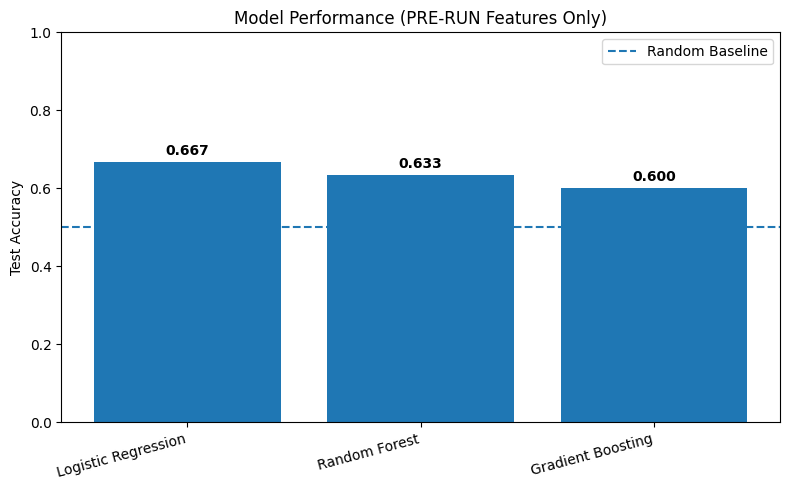

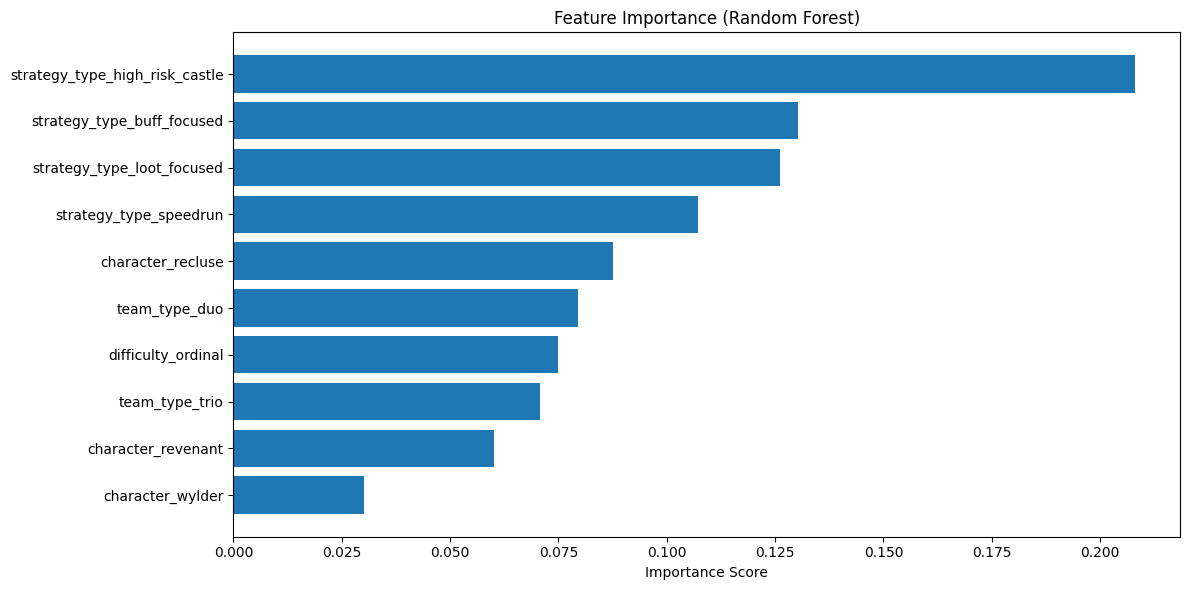

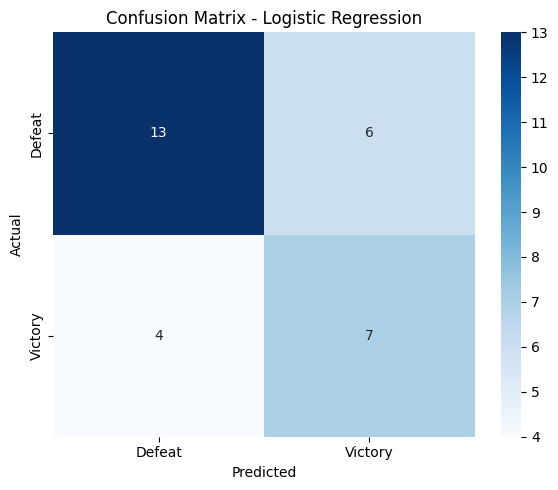

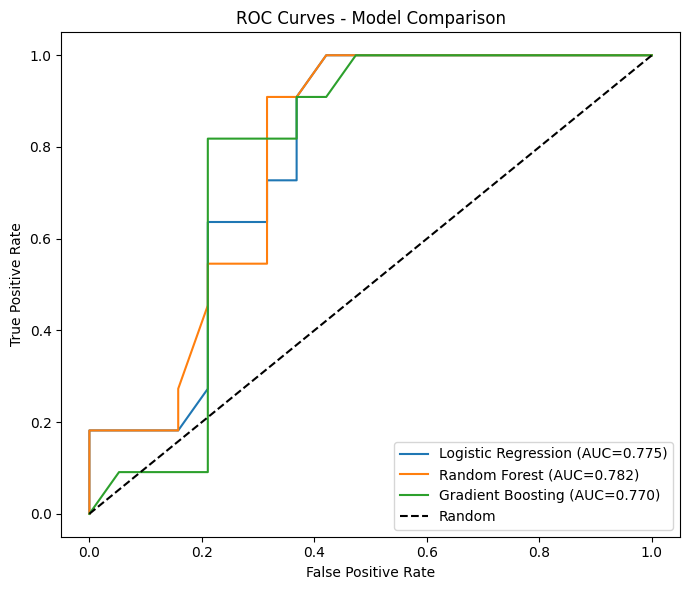

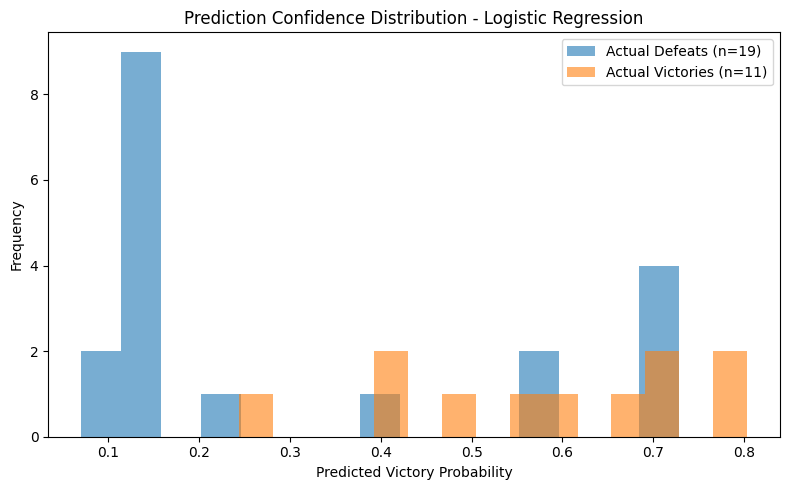

✅ Saved plots to: c:\Users\PC\dsa210_nightreign\dsa210-project-nightreign\results\figures


In [ ]:

# Plot 1: Model performance (Test Accuracy)
plt.figure(figsize=(8, 5))
test_accs = [r["test_acc"] for r in results.values()]
bars = plt.bar(list(results.keys()), test_accs)
plt.ylim(0, 1)
plt.axhline(y=0.5, linestyle="--", label="Random Baseline")
plt.ylabel("Test Accuracy")
plt.title("Model Performance (PRE-RUN Features Only)")
plt.xticks(rotation=15, ha="right")

for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f"{acc:.3f}", ha="center", fontweight="bold")

plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ml_model_performance.png"), dpi=300)
plt.show()

# Plot 2: Feature importance (Top 10)
top_n = min(10, len(feature_importance))
top_features = feature_importance.head(top_n)

plt.figure(figsize=(12, 6))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.xlabel("Importance Score")
plt.title("Feature Importance (Random Forest)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ml_feature_importance.png"), dpi=300)
plt.show()

# Plot 3: Confusion matrix (best model)
cm = confusion_matrix(y_test, best_result["y_pred"])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Defeat", "Victory"],
            yticklabels=["Defeat", "Victory"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ml_confusion_matrix.png"), dpi=300)
plt.show()

# Plot 4: ROC curves
plt.figure(figsize=(7, 6))
for name, result in results.items():
    fpr, tpr, _ = roc_curve(y_test, result["y_proba"])
    plt.plot(fpr, tpr, label=f"{name} (AUC={result['auc']:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - Model Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ml_roc_curves.png"), dpi=300)
plt.show()

# Plot 5: Prediction confidence distribution (best model)
defeats = best_result["y_proba"][y_test == 0]
victories = best_result["y_proba"][y_test == 1]

plt.figure(figsize=(8, 5))
plt.hist(defeats, bins=15, alpha=0.6, label=f"Actual Defeats (n={len(defeats)})")
plt.hist(victories, bins=15, alpha=0.6, label=f"Actual Victories (n={len(victories)})")
plt.xlabel("Predicted Victory Probability")
plt.ylabel("Frequency")
plt.title(f"Prediction Confidence Distribution - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "ml_prediction_confidence.png"), dpi=300)
plt.show()

print("Saved plots to:", os.path.abspath(FIG_DIR))


## 6) Report interpretation

In [9]:
print("\n" + "="*70)
print("REPORT SUMMARY")
print("="*70)

print(f"Best model (by Test Accuracy): {best_model_name}")
print(f"Test Accuracy: {best_result['test_acc']:.3f}")
print(f"ROC-AUC: {best_result['auc']:.3f}")

print("\nTop 5 important pre-run features (RF):")
for _, row in feature_importance.head(5).iterrows():
    print(f"  - {row['Feature']}: {row['Importance']:.3f}")

print("\nClassification report (best model):")
print(classification_report(y_test, best_result["y_pred"], target_names=["Defeat", "Victory"], zero_division=0))



REPORT SUMMARY
Best model (by Test Accuracy): Logistic Regression
Test Accuracy: 0.667
ROC-AUC: 0.775

Top 5 important pre-run features (RF):
  - strategy_type_high_risk_castle: 0.208
  - strategy_type_buff_focused: 0.130
  - strategy_type_loot_focused: 0.126
  - strategy_type_speedrun: 0.107
  - character_recluse: 0.088

Classification report (best model):
              precision    recall  f1-score   support

      Defeat       0.76      0.68      0.72        19
     Victory       0.54      0.64      0.58        11

    accuracy                           0.67        30
   macro avg       0.65      0.66      0.65        30
weighted avg       0.68      0.67      0.67        30



## 7) Limitations & next improvements
- Small dataset → results can vary with a single 80/20 split.
- Prefer **repeated CV** or **bootstrapping** for stability.
- Consider **probability calibration** if you’ll report win probabilities.
- Add more *pre-run* features (if you have them) while keeping leakage rules strict.
